In [36]:
import statistics

import pandas as pd

from helpers import *
from regression import *

In [37]:
pd.set_option('display.max_columns', None)

In [38]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
# find_league_id('GB-ENG', 'Premier League')

In [40]:
CONFIG = {
    'elo_date': '2025-11-29',  # date for elo ratings from clubelo.com
    'opta_date': '2025-11-28',  # date for elo ratings from the opta -> clubelo regression; elo_date from day X is before the games are played, for opta it depends
    'number_of_sims': 10000,
    'league_id': 106,
    'season': 2025,
    'head_size': 106,
    'country_code_elo': None,  # use this attr. to use elo ratings from clubelo.com
    'country_code_api': 'POL',  # use this attr. to use elo ratings from the opta -> clubelo regression
    'stdev': 0,
    'update_fixtures': False,
    'is_european_league': False,
}

In [41]:
download_elo_data(CONFIG['elo_date'])

18 ELO teams matched.
24 Opta teams matched.
44 unmatched Opta teams found, see transformed/opta/opta_unmatched_map.csv:
64 unmatched Opta teams found, see transformed/opta/opta_unmatched_elo_df.csv:
18 teams used for regression.
0.9669 R^2 score
y = 27.49 * x + -689.38


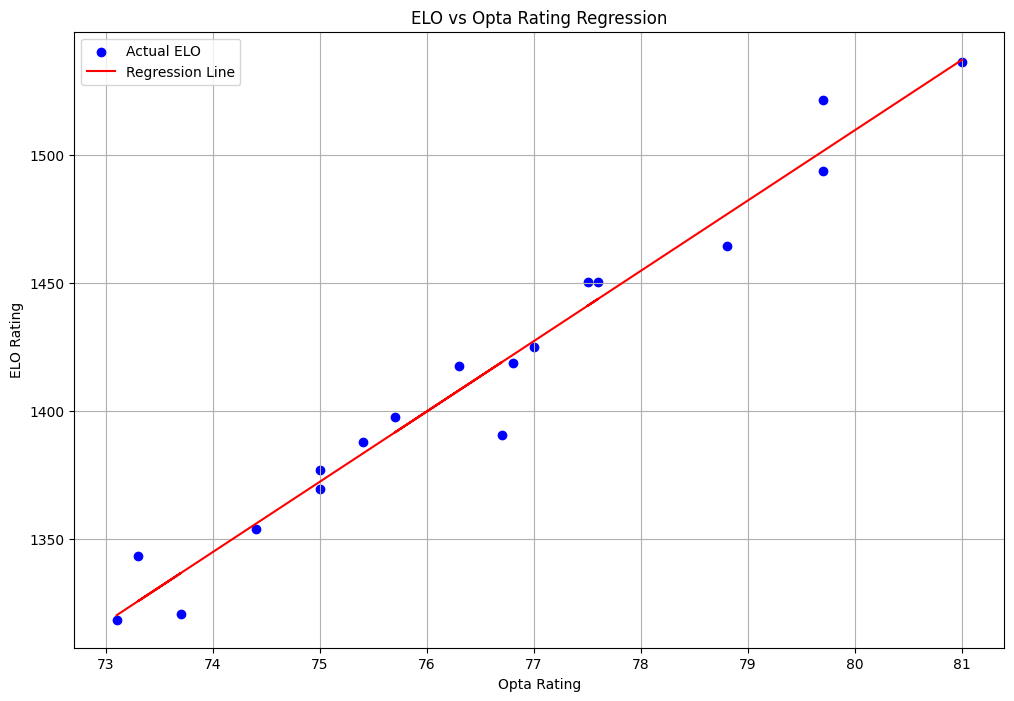

In [42]:
main_regression(**CONFIG)

In [43]:
standings_df = build_historical_standings_table_after_at_most_n_rounds(**CONFIG)
standings_df.head(CONFIG['head_size'])

,Club,Elo,Points,Games played
1,Gornik Zabrze,1522.41,30,17
2,Jagiellonia,1542.73,27,14
3,Wisla Plock,1474.99,27,15
4,Radomiak Radom,1452.41,25,17
5,Cracovia Krakow,1481.76,25,16
6,Lech Poznan,1542.73,24,15
7,Raków Częstochowa,1572.08,23,15
8,Korona Kielce,1477.25,23,17
9,Lechia Gdansk,1423.06,22,17
10,Zaglebie Lubin,1445.64,21,15


In [44]:
# avg points per game
float(round(standings_df['Points'].sum() / standings_df['Games played'].sum(), 2))

1.37

In [45]:
standings_df['Points'] = standings_df.apply(lambda x: x['Points']-5 if x['Club'] == 'Lechia Gdansk' else x['Points'], axis=1)
standings_df.head(CONFIG['head_size'])

,Club,Elo,Points,Games played
1,Gornik Zabrze,1522.41,30,17
2,Jagiellonia,1542.73,27,14
3,Wisla Plock,1474.99,27,15
4,Radomiak Radom,1452.41,25,17
5,Cracovia Krakow,1481.76,25,16
6,Lech Poznan,1542.73,24,15
7,Raków Częstochowa,1572.08,23,15
8,Korona Kielce,1477.25,23,17
9,Lechia Gdansk,1423.06,17,17
10,Zaglebie Lubin,1445.64,21,15


In [46]:
sample_season = simulate_season_after_n_rounds(**CONFIG, standings_df=standings_df)
sample_season.head(CONFIG['head_size'])

,Club,Points,Elo,Games played
0,Gornik Zabrze,60,1522.41,34
15,Legia Warszawa,60,1495.31,34
6,Raków Częstochowa,58,1572.08,34
1,Jagiellonia,54,1542.73,34
2,Wisla Plock,54,1474.99,34
5,Lech Poznan,52,1542.73,34
14,Arka Gdynia,46,1407.25,34
17,Piast Gliwice,46,1465.96,34
7,Korona Kielce,45,1477.25,34
4,Cracovia Krakow,44,1481.76,34


In [47]:
# verify that the % of draws in simulated season is similar to the actual results
float(round(sample_season['Points'].sum() / sample_season['Games played'].sum(), 2))

1.36

In [48]:
# full table sim
results = run_full_table_sims(**CONFIG, standings_df=standings_df)
results.head(CONFIG['head_size'])

100%|██████████| 10000/10000 [00:53<00:00, 188.27it/s]

10000 simulations


,Club,Elo,xPts,Top 4,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
1,Jagiellonia,1542.73,59.30,85.0,41.7,21.4,13.5,8.4,5.7,3.6,2.2,1.6,0.8,0.4,0.3,0.2,0.1,0.1,0.0,0.0,0.0,0.0
2,Gornik Zabrze,1522.41,55.83,68.8,16.9,19.7,18.1,14.2,10.6,7.1,5.2,3.3,2.1,1.2,0.6,0.5,0.3,0.2,0.1,0.0,0.0,0.0
3,Raków Częstochowa,1572.08,55.77,68.3,17.6,19.6,17.3,13.8,10.5,7.2,4.7,3.2,2.1,1.7,1.0,0.6,0.3,0.2,0.1,0.1,0.0,0.0
4,Lech Poznan,1542.73,53.77,54.1,10.7,13.6,15.1,14.6,12.1,9.8,7.3,5.0,3.9,2.7,2.1,1.2,0.7,0.6,0.3,0.1,0.1,0.0
5,Wisla Plock,1474.99,52.67,45.3,7.5,11.5,12.6,13.7,12.4,11.5,8.5,6.8,5.2,3.6,2.2,2.0,1.0,0.7,0.5,0.2,0.1,0.0
6,Cracovia Krakow,1481.76,50.15,28.0,2.9,6.5,8.3,10.3,11.7,12.1,11.1,9.3,7.6,5.9,4.6,3.3,2.6,1.7,1.2,0.6,0.3,0.2
7,Radomiak Radom,1452.41,46.95,11.2,0.8,1.9,3.2,5.2,7.4,9.3,10.3,10.8,10.1,9.6,8.3,6.9,5.3,4.2,3.3,1.9,1.0,0.3
8,Korona Kielce,1477.25,46.83,11.2,0.7,1.6,3.6,5.4,7.2,8.9,10.7,10.1,10.3,9.7,8.3,7.1,5.7,4.0,3.2,2.1,1.1,0.4
9,Legia Warszawa,1495.31,45.31,7.6,0.4,1.2,2.1,4.0,5.6,6.9,8.2,9.5,9.0,9.4,9.1,8.3,7.2,6.7,4.4,3.9,2.7,1.3
10,Zaglebie Lubin,1445.64,45.01,7.0,0.5,1.2,2.0,3.3,5.0,6.5,7.6,9.2,9.1,9.6,9.6,8.4,7.7,6.5,5.4,4.1,2.7,1.5


In [49]:
# bottom 3
results = run_multiple_sims(**CONFIG, standings_df=standings_df, number_of_winning_places=3, reverse=True)
results.head(CONFIG['head_size'])

100%|██████████| 10000/10000 [00:47<00:00, 208.61it/s]

10000 simulations
3 winning places
Reverse: TRUE


,Club,xPts,RTB Wins,LTB Wins,% RTB winrate,% LTB winrate,Exp. RTB odds,Exp. LTB odds
1,Nieciecza,35.23,6730,6439,67.3,64.4,1.49,1.55
2,Lechia Gdansk,37.67,4875,4531,48.8,45.3,2.05,2.21
3,Arka Gdynia,38.84,3951,3640,39.5,36.4,2.53,2.75
4,Widzew Łódź,39.00,3808,3456,38.1,34.6,2.63,2.89
5,Piast Gliwice,39.46,3484,3188,34.8,31.9,2.87,3.14
6,GKS Katowice,41.93,1966,1752,19.7,17.5,5.09,5.71
7,Motor Lublin,42.67,1687,1494,16.9,14.9,5.93,6.69
8,Pogon Szczecin,44.62,884,741,8.8,7.4,11.31,13.50
9,Zaglebie Lubin,45.00,862,725,8.6,7.2,11.60,13.79
10,Legia Warszawa,45.33,839,716,8.4,7.2,11.92,13.97
